In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

pd.set_option("display.max_columns", None)

os.makedirs("../reports", exist_ok=True)

In [4]:
df = pd.read_csv("../data/AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


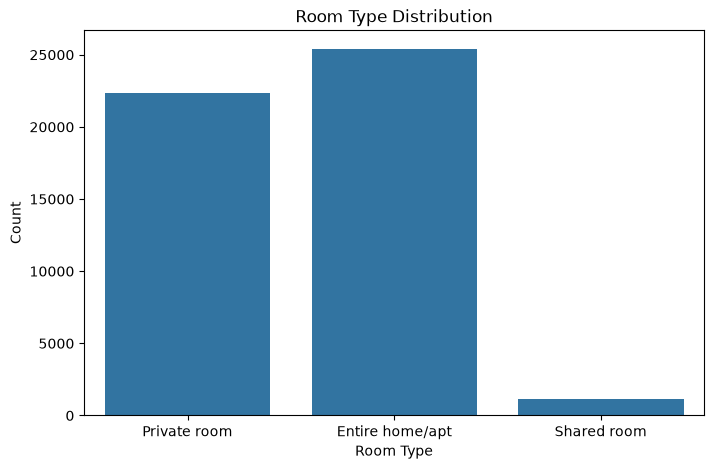

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")

plt.savefig(
    "../reports/room_types.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
df.shape

(48895, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [7]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


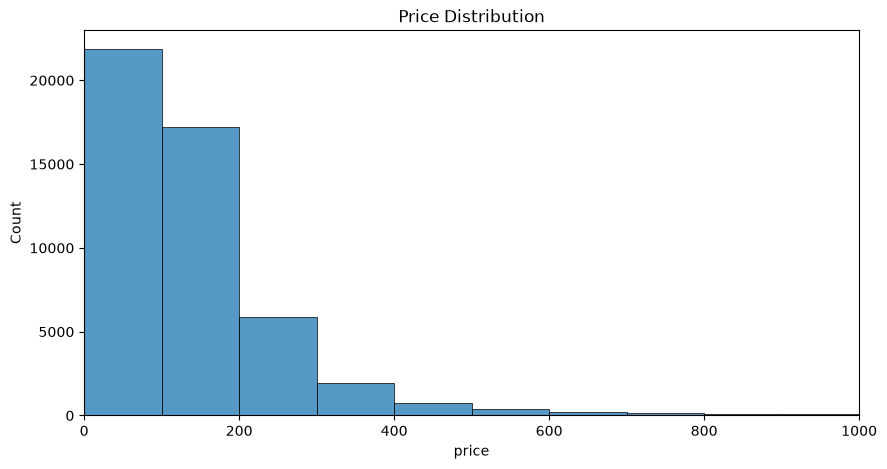

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=100)

plt.xlim(0,1000)

plt.title("Price Distribution")

plt.savefig(
    "../reports/price_distribution.png",
    bbox_inches="tight"
)

plt.show()

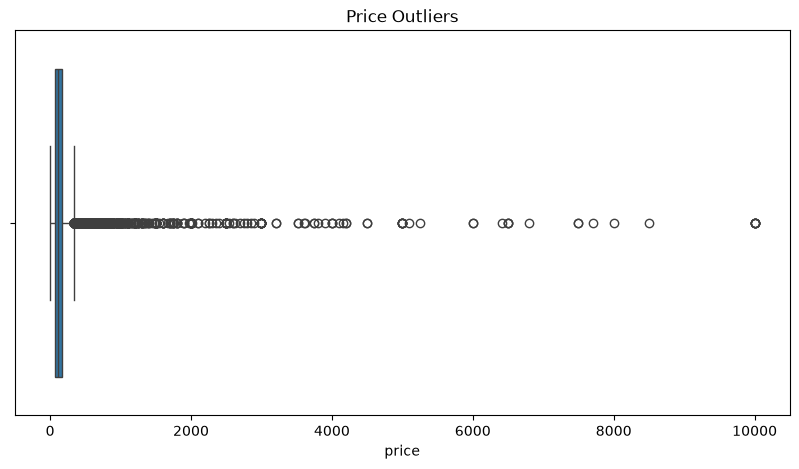

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["price"])

plt.title("Price Outliers")

plt.savefig(
    "../reports/price_outliers.png",
    bbox_inches="tight"
)

plt.show()

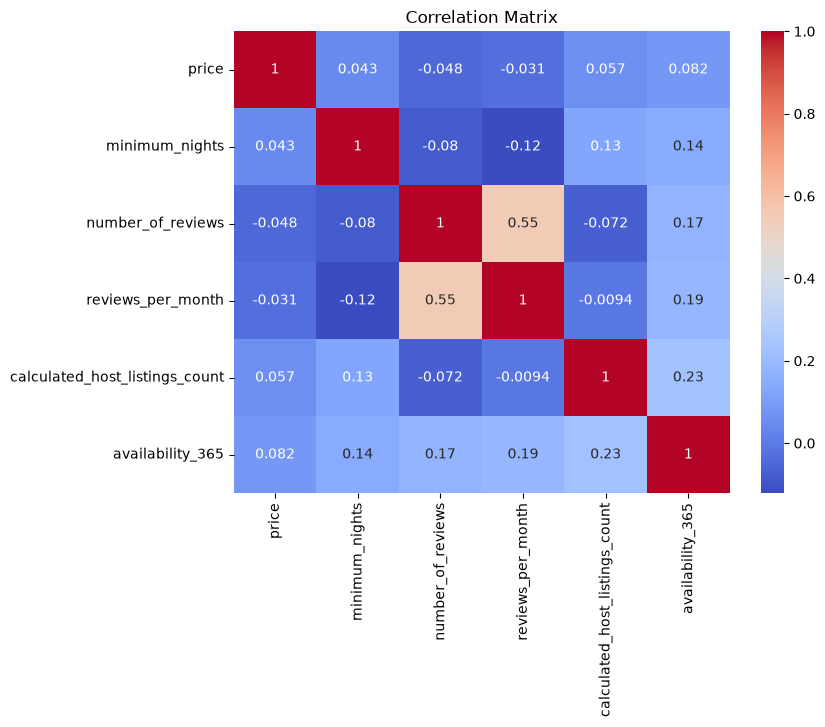

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Room Type Distribution")

plt.xticks(rotation=20)

plt.savefig(
    "../reports/room_types.png",
    bbox_inches="tight"
)

plt.show()

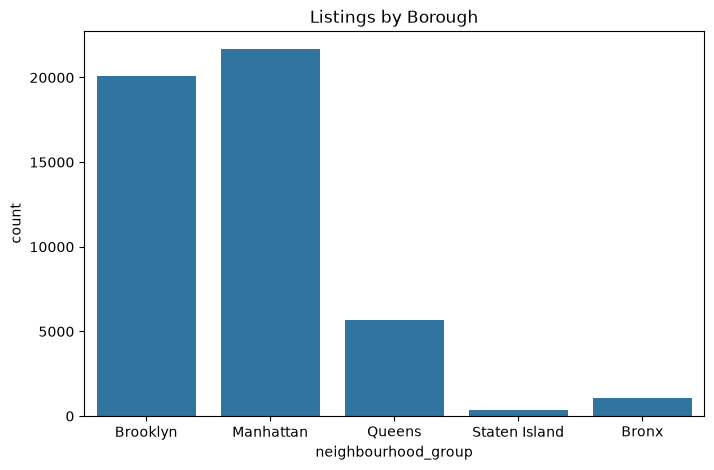

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="neighbourhood_group"
)

plt.title("Listings by Borough")

plt.savefig(
    "../reports/borough_listings.png",
    bbox_inches="tight"
)

plt.show()

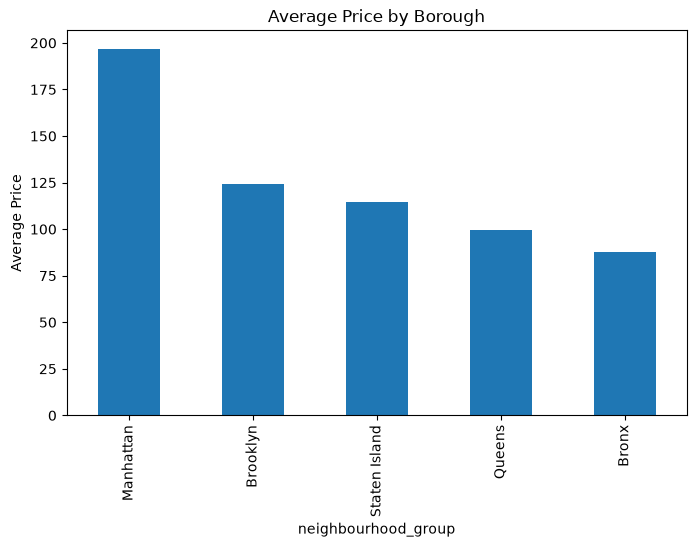

In [17]:
borough_price = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

borough_price.plot(kind="bar")

plt.title("Average Price by Borough")

plt.ylabel("Average Price")

plt.savefig(
    "../reports/borough_prices.png",
    bbox_inches="tight"
)

plt.show()

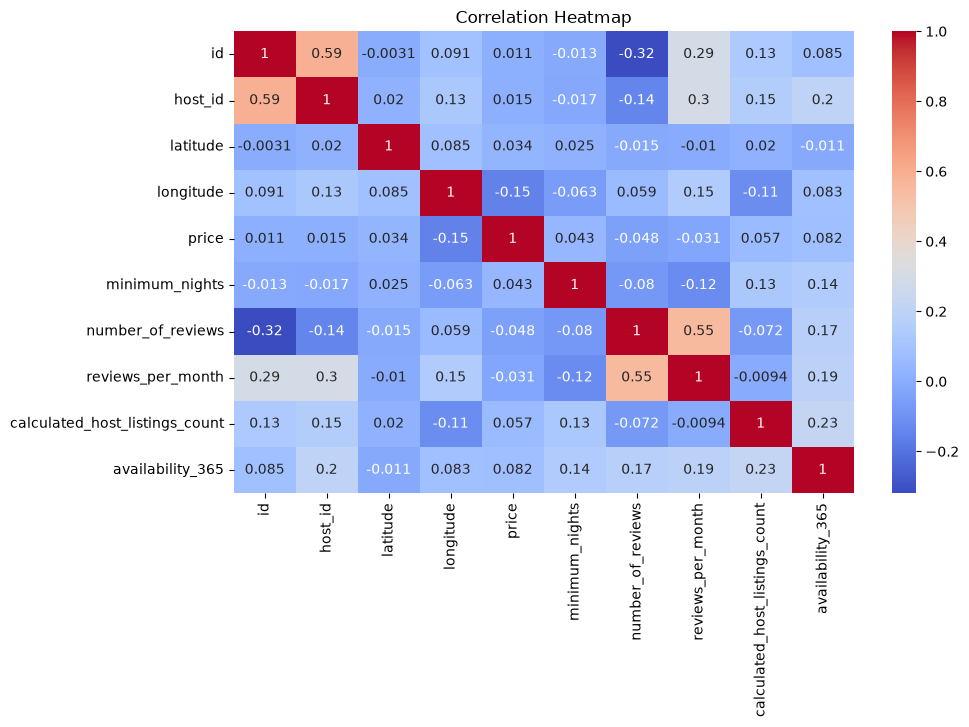

In [18]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../reports/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
top_hosts = (
    df.groupby("host_name")["id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_hosts

host_name
Michael         417
David           403
Sonder (NYC)    327
John            294
Alex            279
Blueground      232
Sarah           227
Daniel          226
Jessica         205
Maria           204
Name: id, dtype: int64

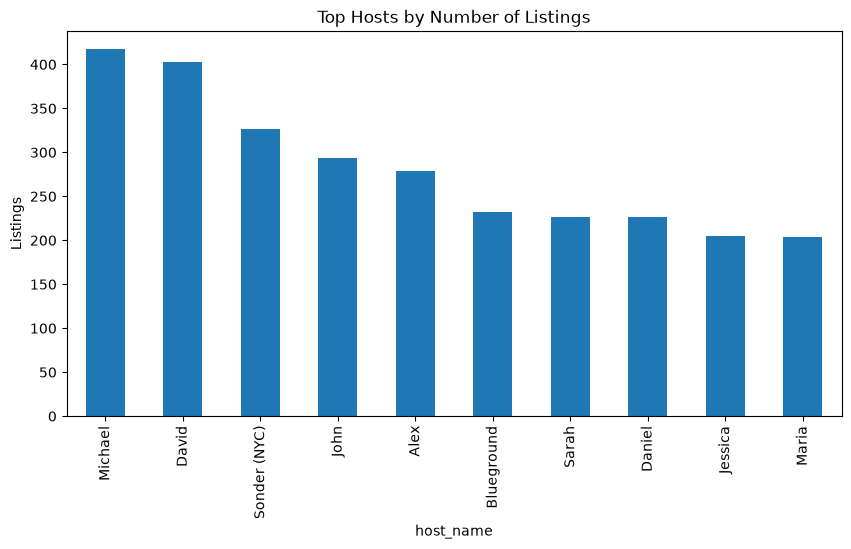

In [20]:
plt.figure(figsize=(10,5))

top_hosts.plot(kind="bar")

plt.title("Top Hosts by Number of Listings")

plt.ylabel("Listings")

plt.savefig(
    "../reports/top_hosts.png",
    bbox_inches="tight"
)

plt.show()

In [21]:
df.groupby("neighbourhood_group")["price"] \
.mean() \
.sort_values(ascending=False)

neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

In [22]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [23]:
df[
    ["name", "neighbourhood_group", "price"]
].sort_values(
    by="price",
    ascending=False
).head(10)

,name,neighbourhood_group,price
29238,1-BR Lincoln Center,Manhattan,10000
9151,Furnished room in Astoria apartment,Queens,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,10000
6530,Spanish Harlem Apt,Manhattan,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,9999
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,8500
4377,Film Location,Brooklyn,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,7703
42523,70' Luxury MotorYacht on the Hudson,Manhattan,7500


In [24]:
df.groupby("room_type")["price"] \
.mean() \
.sort_values(ascending=False)

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

In [26]:
df.to_csv(
    "../data/cleaned_airbnb.csv",
    index=False
)

In [27]:
import os

os.listdir("../reports")

['borough_listings.png',
 'borough_prices.png',
 'correlation_heatmap.png',
 'price_distribution.png',
 'price_outliers.png',
 'room_types.png',
 'top_hosts.png']